# Problem Set 10 — Inferring cosmology from the Planck CMB spectrum with NPE

**Starter notebook.** The background and the full task descriptions are on the worksheet
(`ProblemSet10_2026.pdf`). This notebook gives you the data loader, the prior, and the plotting
helpers; you fill in the tasks (`# TODO`).

We infer the matter and baryon densities $(\Omega_m, \Omega_b)$ around their fiducial Planck 2018
values $\Omega_m = 0.3153 \pm 0.0073$, $\Omega_b = 0.0494 \pm 0.0003$ (i.e.
$\Omega_b h^2 = 0.02238 \pm 0.00015$). The $\pm$ values are the Planck 2018 $1\sigma$ errors, and
the uniform prior spans $\pm 4\sigma$ around the fiducial. All other parameters are held fixed:
$H_0 = 67.32$ km/s/Mpc, $n_s = 0.9661$, $\ln(10^{10}A_s) = 3.045$, $\tau = 0.0543$.

The CAMB simulations are shipped in `planck_camb_tt.h5`, so you do **not** need CAMB
installed — the loader is provided. Reference: the NPE recipe in `lecture_10_NPE.ipynb`. (If you
do have CAMB and want to rebuild the data, run `python make_planck_npe_data.py`.)

## 0. Setup

In [1]:
pip install sbi

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for nflows: filename=nflows-0.14-py3-none-any.whl size=53730 sha256=7e09feee14dfc850c1fdef0be463632404f71adbc45ec356bbee122c7f32972d
  Stored in directory: c:\users\ahmet\appdata\local\pip\cache\wheels\ca\8f\ac\c324eb57b461632081812c33b13161878290d0e6fbb8f5a7e2
Successfully built nflows

   -------- ------------------------------- 1/5 [zuko]
   -------- ------------------------------- 1/5 [zuko]
   ---------------- ----------------------- 2/5 [skorch]
   ---------------- ----------------------- 2/5 [skorch]
   ---------------- ----------------------- 2/5 [skorch]
   ---------------- ----------------------- 2/5 [skorch]
   ---------------- -------


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
import torch

from sbi.inference import NPE
from sbi.utils import BoxUniform
from sbi.diagnostics import run_sbc, check_sbc

In [4]:
from make_planck_npe_data import load_planck_npe_data

%matplotlib inline
torch.set_default_dtype(torch.float32)
torch.manual_seed(7)
rng = np.random.default_rng(7)

theta_labels = [r"$\Omega_m$", r"$\Omega_b$"]
print("setup ok")

setup ok


## 1. Load the simulations  *(Task 1)*

Load the training bank from `planck_camb_tt.h5` and set up the prior. The file holds
`theta` $=(\Omega_m,\Omega_b)$ and the corresponding **clean** (noise-free) CAMB spectra
`spectra`, plus the multipoles `ell`, the fiducial cosmology, and the Planck observation
(used later). *This cell is provided.*

In [5]:
data = load_planck_npe_data()

theta = torch.as_tensor(data.theta, dtype=torch.float32)        # (n, 2)
spectra = torch.as_tensor(data.spectra, dtype=torch.float32)    # (n, n_ell), CLEAN
ell = data.ell
fid_theta = data.fid_theta
fid_spectrum = data.fid_spectrum

prior = BoxUniform(low=torch.as_tensor(data.prior_low, dtype=torch.float32),
                   high=torch.as_tensor(data.prior_high, dtype=torch.float32))

n_sims, n_features = spectra.shape
print(f"{n_sims} simulations, {n_features} multipoles, ell in [{ell.min():.0f}, {ell.max():.0f}]")
print("prior low :", np.asarray(data.prior_low))
print("prior high:", np.asarray(data.prior_high))
print("fiducial  :", fid_theta)

2000 simulations, 1499 multipoles, ell in [2, 1500]
prior low : [0.2861     0.04806506]
prior high: [0.3445     0.05071291]
fiducial  : [0.3153     0.04938898]


## 2. Plot the prior-predictive spectra  *(Task 2)*

Plot a random sample (~40) of the clean training spectra and overlay the fiducial spectrum, to
see how much the spectrum moves as $(\Omega_m,\Omega_b)$ vary across the prior.

In [6]:
# Task 2: plot ~40 prior-predictive spectra (light blue) and overlay the fiducial (black).

#Hint: idx = rng.choice(n_sims, size=40, replace=False),loop ax.plot(ell, spectra[j].numpy(), ...)
#ax.plot(ell, fid_spectrum, "k-", label="fiducial").
#raise NotImplementedError("Task 2: plot the prior-predictive spectra")

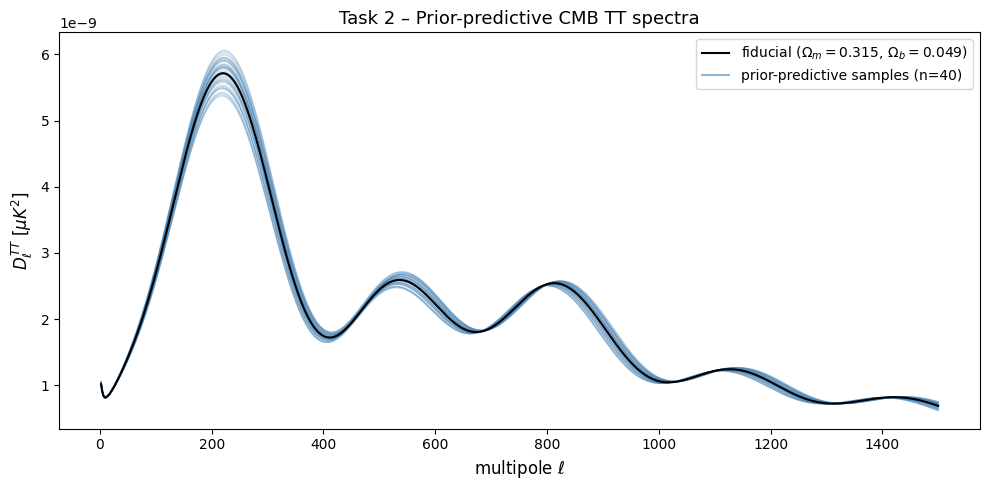

In [7]:
rng = np.random.default_rng(42)
idx = rng.choice(n_sims, size=40, replace=False)

fig, ax = plt.subplots(figsize=(10, 5))

for j in idx:
    ax.plot(ell, spectra[j].numpy(), color="steelblue", alpha=0.3, linewidth=0.8)

# Overlay fiducial spectrum
ax.plot(ell, fid_spectrum, "k-", linewidth=1.5, label="fiducial ($\\Omega_m=0.315,\\, \\Omega_b=0.049$)")

ax.plot([], [], color="steelblue", alpha=0.6, label="prior-predictive samples (n=40)")

ax.set_xlabel(r"multipole $\ell$", fontsize=12)
ax.set_ylabel(r"$D_\ell^{TT}\ [\mu K^2]$", fontsize=12)
ax.set_title("Task 2 – Prior-predictive CMB TT spectra", fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("task2_prior_predictive.png", dpi=150)
plt.show()

## 3. Load the Planck data  *(Task 3)*

Extract the official unbinned Planck TT observation from `data` and plot it with its error bars,
together with the fiducial CAMB spectrum. You will infer the cosmology from exactly this data
vector in Task 6.

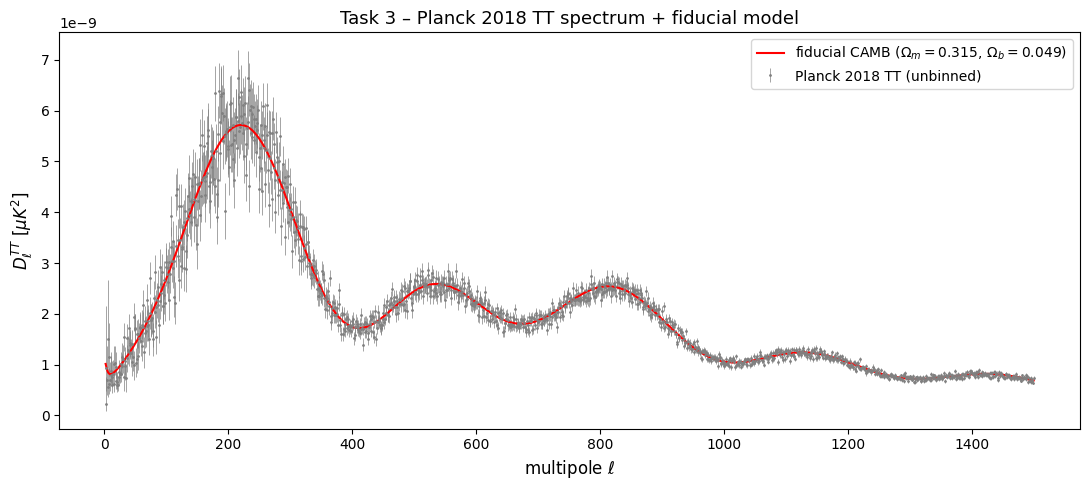

In [8]:
# Task 3: pull the Planck observation from `data` and plot it with error bars.
# Assign these (used again in Tasks 4, 6, 7):
#   planck_dl, planck_err_minus, planck_err_plus, planck_sigma  =  data.<...>
# Hint: ax.errorbar(ell, planck_dl, yerr=[planck_err_minus, planck_err_plus], fmt=".")
#raise NotImplementedError("Task 3: load and plot the Planck spectrum")


planck_dl        = data.planck_dl         
planck_err_minus = data.planck_err_minus
planck_err_plus  = data.planck_err_plus
planck_sigma     = data.planck_sigma

fig, ax = plt.subplots(figsize=(11, 5))

# Planck data with asymmetric error bars
ax.errorbar(
    ell, planck_dl,
    yerr=[planck_err_minus, planck_err_plus],
    fmt=".", color="grey", markersize=2,
    linewidth=0.5, capsize=0,
    label="Planck 2018 TT (unbinned)"
)

# Fiducial CAMB spectrum
ax.plot(ell, fid_spectrum, "r-", linewidth=1.5,
        label=r"fiducial CAMB ($\Omega_m=0.315,\,\Omega_b=0.049$)")

ax.set_xlabel(r"multipole $\ell$", fontsize=12)
ax.set_ylabel(r"$D_\ell^{TT}\ [\mu K^2]$", fontsize=12)
ax.set_title("Task 3 – Planck 2018 TT spectrum + fiducial model", fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("task3_planck_data.png", dpi=150)
plt.show()

## 4. Add measurement errors — cosmic variance  *(Task 4)*

The shipped spectra are **noise-free**. Build a diagonal noise model and apply it to every training
spectrum, so the network learns from data that look like the real, noisy Planck observation.

The per-multipole variance is cosmic variance (which **scales with the spectrum**, Knox formula)
plus a fixed instrument floor:

$$\sigma_\ell^2(\theta) = \underbrace{\frac{2}{(2\ell+1)\,f_{\rm sky}}\,D_\ell(\theta)^2}_{\text{cosmic variance}} + \sigma_{{\rm floor},\ell}^2 .$$

Calibrate the floor **once** so the fiducial cosmology reproduces the Planck error bars:
$\sigma_{{\rm floor},\ell}^2 = \max\!\big(\sigma_\ell^{\rm Planck\,2} - \sigma_{\rm cv}(D_\ell^{\rm fid})^2,\,0\big)$.
Then standardize the features $(x-\mu)/\sigma$ before training.

In [9]:
# Task 4: build the measurement-noise model and apply it to the CLEAN spectra.
#  (a) cosmic_variance_sigma(D_ell) = sqrt(2/((2*ell+1)*F_SKY)) * D_ell           (Knox formula)
#  (b) sigma_floor (fixed): calibrate so the FIDUCIAL total error matches Planck:
#         sigma_floor^2 = clip(planck_sigma^2 - cosmic_variance_sigma(fid_spectrum)^2, 0, None)
#  (c) add_noise(clean): draw Normal(0, sqrt(sigma_cv(clean)^2 + sigma_floor^2)) and add it
#  (d) x_all = standardized (x - mean) / std of the noised spectra
#  Also define standardize(dl) so you can reuse mu/sigma on the Planck vector in Task 6.
F_SKY = 1.0
#raise NotImplementedError("Task 4: cosmic-variance noise + standardization")

In [10]:
def cosmic_variance_sigma(D_ell):
    
    ell_t = torch.as_tensor(ell, dtype=torch.float32)
    cv = torch.sqrt(torch.tensor(2.0) / ((2.0 * ell_t + 1.0) * F_SKY))
    return cv * torch.as_tensor(D_ell, dtype=torch.float32)

fid_t          = torch.as_tensor(fid_spectrum,  dtype=torch.float32)
planck_sigma_t = torch.as_tensor(planck_sigma,  dtype=torch.float32)

sigma_cv_fid   = cosmic_variance_sigma(fid_t)
sigma_floor_sq = torch.clamp(planck_sigma_t**2 - sigma_cv_fid**2,min=0.0)
sigma_floor    = torch.sqrt(sigma_floor_sq)  

In [11]:
def add_noise(clean: torch.Tensor) -> torch.Tensor:
    sigma_cv  = cosmic_variance_sigma(clean)
    sigma_tot = torch.sqrt(sigma_cv**2 + sigma_floor_sq)
    noise     = torch.randn_like(clean) * sigma_tot
    return clean + noise

torch.manual_seed(0)
spectra_noisy = add_noise(spectra.float())

In [12]:
mu_ell    = spectra_noisy.mean(dim=0)
std_ell   = spectra_noisy.std(dim=0)

def standardize(dl: torch.Tensor) -> torch.Tensor:
    """Apply training normalisation to any spectrum (or batch)."""
    return (torch.as_tensor(dl, dtype=torch.float32) - mu_ell) / std_ell

x_all = standardize(spectra_noisy)

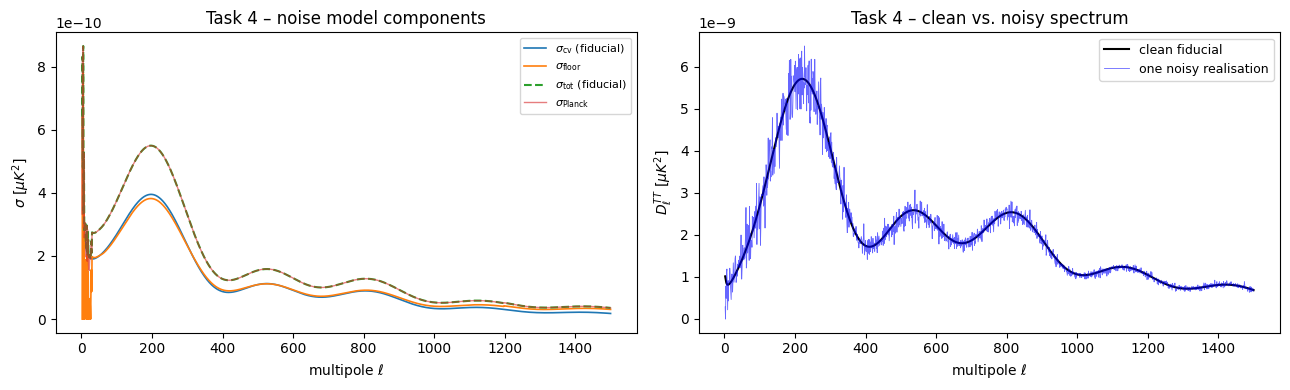

x_all shape : torch.Size([2000, 1499])
mu_ell  range: [0.0, 0.0]
std_ell range: [0.0, 0.0]


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(ell, sigma_cv_fid.numpy(),   label=r"$\sigma_{\rm cv}$ (fiducial)", lw=1.2)
ax.plot(ell, sigma_floor.numpy(),    label=r"$\sigma_{\rm floor}$",          lw=1.2)
total_fid = torch.sqrt(sigma_cv_fid**2 + sigma_floor_sq)
ax.plot(ell, total_fid.numpy(),      label=r"$\sigma_{\rm tot}$ (fiducial)", lw=1.5, ls="--")
ax.plot(ell, planck_sigma,           label=r"$\sigma_{\rm Planck}$",         lw=1.0, alpha=0.6)
ax.set_xlabel(r"multipole $\ell$"); ax.set_ylabel(r"$\sigma\ [\mu K^2]$")
ax.set_title("Task 4 – noise model components"); ax.legend(fontsize=8)

ax = axes[1]
ax.plot(ell, fid_spectrum,              "k-",  lw=1.5, label="clean fiducial")
ax.plot(ell, spectra_noisy[0].numpy(), "b-",  lw=0.6, alpha=0.6, label="one noisy realisation")
ax.set_xlabel(r"multipole $\ell$"); ax.set_ylabel(r"$D_\ell^{TT}\ [\mu K^2]$")
ax.set_title("Task 4 – clean vs. noisy spectrum"); ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("task4_noise_model.png", dpi=150)
plt.show()

print(f"x_all shape : {x_all.shape}")
print(f"mu_ell  range: [{mu_ell.min():.1f}, {mu_ell.max():.1f}]")
print(f"std_ell range: [{std_ell.min():.1f}, {std_ell.max():.1f}]")

## 5. Train the NPE  *(Task 5)*

Train an amortized NPE, exactly as in `lecture_10_NPE.ipynb` §2:
`NPE(prior)` → `append_simulations(theta, x).train()` → `build_posterior(...)`.
Hold out the **last `n_test = 300`** simulations — you will use them for the coverage test in Task 7.

In [25]:
# Task 5: train an amortized NPE (mirror lecture_10_NPE.ipynb section 2).
n_test = 300
theta_train, x_train = theta[:-n_test], x_all[:-n_test]
theta_sbc, x_sbc = theta[-n_test:], x_all[-n_test:]
inference = NPE(prior=prior)
inference.append_simulations(theta_train, x_train).train(max_num_epochs=120)
posterior = inference.build_posterior()

 Neural network successfully converged after 27 epochs.

## 6. Posterior for the Planck spectrum  *(Task 6)*

Plotting helpers are provided below (2-D credible contours + 1-D marginals, with an optional
truth marker and error bars). *This cell is provided — just run it.*

In [22]:
from scipy.ndimage import gaussian_filter

def credible_levels_from_samples(samples, bins=80, masses=(0.95, 0.68)):
    H, xe, ye = np.histogram2d(samples[:, 0], samples[:, 1], bins=bins, density=True)
    H = gaussian_filter(H.T, sigma=1.2)
    dx, dy = xe[1] - xe[0], ye[1] - ye[0]
    flat = np.sort(H.ravel())[::-1]
    csum = np.cumsum(flat) * dx * dy
    levels = sorted(flat[min(np.searchsorted(csum, m), len(flat) - 1)] for m in masses)
    xc, yc = 0.5 * (xe[:-1] + xe[1:]), 0.5 * (ye[:-1] + ye[1:])
    X, Y = np.meshgrid(xc, yc)
    return X, Y, H, levels

def draw_posterior(samples, truth=None, truth_err=None, title="Posterior"):
    samples = np.asarray(samples)
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
    X, Y, H, levels = credible_levels_from_samples(samples)
    axes[0].contour(X, Y, H, levels=levels, colors=["tab:blue", "navy"], linewidths=[1.2, 1.8])
    axes[0].scatter(samples[:, 0], samples[:, 1], s=2, alpha=0.03, color="tab:blue", rasterized=True)
    if truth is not None:
        if truth_err is not None:
            axes[0].errorbar(truth[0], truth[1], xerr=truth_err[0], yerr=truth_err[1],
                             fmt="r*", ms=13, ecolor="r", capsize=3, label="Planck 2018")
        else:
            axes[0].plot(truth[0], truth[1], "r*", ms=13, label="fiducial")
        axes[0].legend(fontsize=8)
    axes[0].set_xlabel(theta_labels[0]); axes[0].set_ylabel(theta_labels[1]); axes[0].set_title(title)
    for j, ax in enumerate(axes[1:]):
        ax.hist(samples[:, j], bins=60, density=True, color="tab:blue", alpha=0.65)
        if truth is not None:
            ax.axvline(truth[j], color="r", ls=":", lw=2)
            if truth_err is not None:
                ax.axvspan(truth[j] - truth_err[j], truth[j] + truth_err[j], color="r", alpha=0.12)
        ax.set_xlabel(theta_labels[j]); ax.set_ylabel("density")
    plt.tight_layout()
    return fig, axes

Now sample the posterior at the Planck data vector and plot it. Mark the Planck 2018 fiducial
with its published 1-$\sigma$ error bars. Does the contour cover the fiducial?

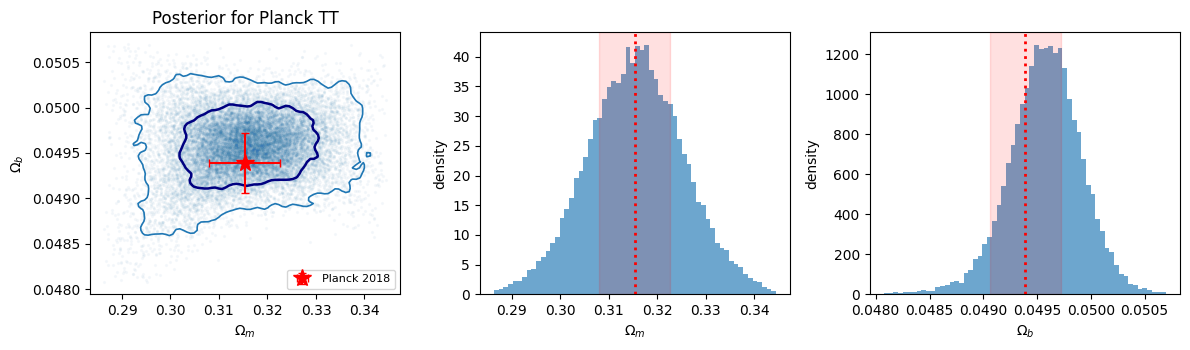

In [27]:
# Task 6: sample the posterior at the Planck data vector and plot it with draw_posterior().
# Mark the Planck 2018 fiducial with its 1-sigma error bars:
omega_b_sigma = 0.00015 / data.h**2 ; truth_err = [0.0073, omega_b_sigma]
x_planck = standardize(planck_dl).reshape(1, -1)
planck_samples = posterior.sample((20000,), x=x_planck, show_progress_bars=False).numpy()
draw_posterior(
    planck_samples,
    truth=fid_theta,
    truth_err=truth_err,
    title="Posterior for Planck TT"
)

plt.show()


## 7. Checks — coverage & posterior predictive  *(Task 7)*

A neural posterior *always* returns an answer; these checks ask whether to trust it.

**(a) Coverage / SBC.** On the held-out simulations (`theta[-n_test:]`, `x_all[-n_test:]`), run
simulation-based calibration: rank each true value among posterior draws. Flat rank histograms =
calibrated; $\cup$-shaped = overconfident.

**(b) Posterior-predictive check (PPC) — _optional_.** Draw parameters from the Planck posterior
and look at the spectra they imply — they should straddle the Planck data. Without CAMB at
inference time, approximate the simulator by the **nearest pre-computed training spectrum**
(`scipy.spatial.cKDTree`). *(With CAMB you would resimulate exactly via
`make_planck_npe_data.camb_tt_spectrum`.)*

Drawing 200 samples for 300 observations:   0%|          | 0/200 [00:00<?, ?it/s]

Calculating ranks for 300 SBC samples:   0%|          | 0/300 [00:00<?, ?it/s]

Drawing 200 samples for 300 observations:   0%|          | 0/200 [00:00<?, ?it/s]

Calculating ranks for 300 SBC samples:   0%|          | 0/300 [00:00<?, ?it/s]

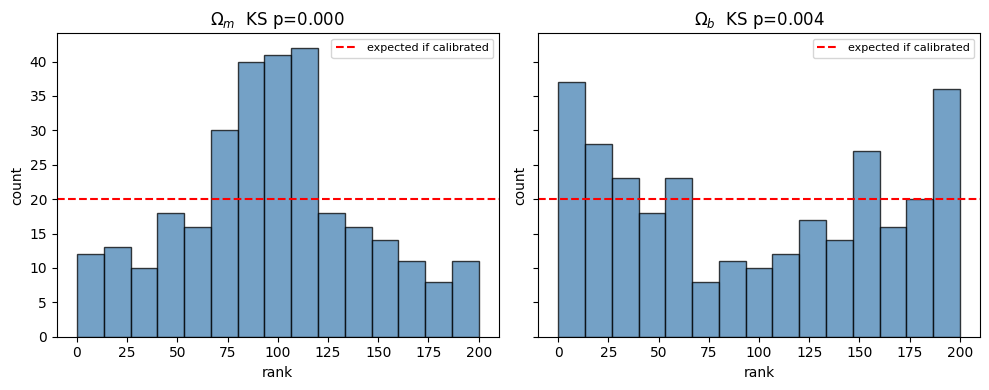

In [28]:
# Task 7a (coverage / SBC): use the held-out sims theta[-n_test:], x_all[-n_test:].
ranks, dap = run_sbc(theta_sbc, x_sbc, posterior, num_posterior_samples=200)
ks = check_sbc(ranks, theta_sbc, dap, num_posterior_samples=200)["ks_pvals"]

# Task 7a: coverage / SBC

ranks, dap = run_sbc(
    theta_sbc,
    x_sbc,
    posterior,
    num_posterior_samples=200
)

ks = check_sbc(
    ranks,
    theta_sbc,
    dap,
    num_posterior_samples=200
)["ks_pvals"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

for j, ax in enumerate(axes):
    ax.hist(
        ranks[:, j],
        bins=15,
        range=(0, 200),
        color="steelblue",
        edgecolor="black",
        alpha=0.75
    )

    ax.axhline(
        len(theta_sbc) / 15,
        color="red",
        linestyle="--",
        label="expected if calibrated"
    )

    ax.set_title(f"{theta_labels[j]}  KS p={ks[j]:.3f}")
    ax.set_xlabel("rank")
    ax.set_ylabel("count")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


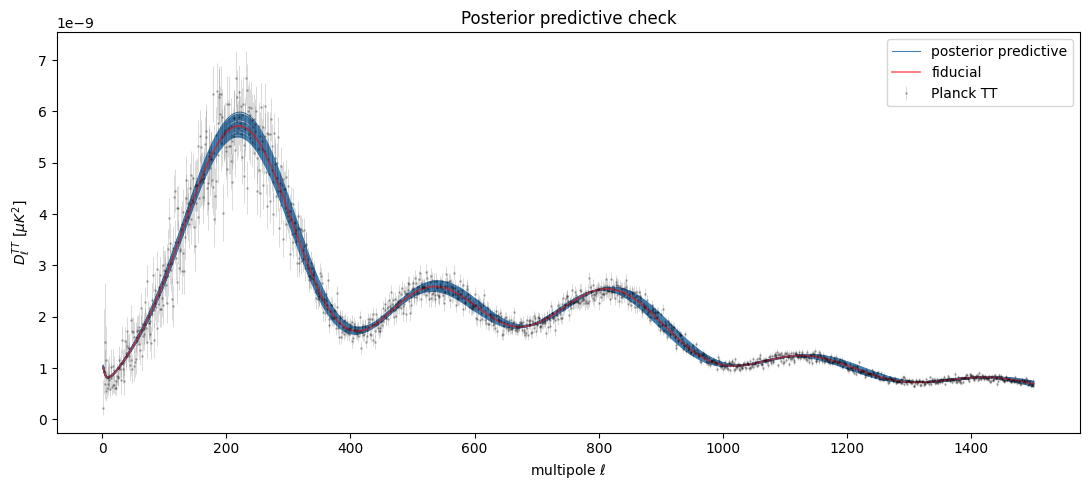

In [38]:
# Task 7b (OPTIONAL — PPC): draw ~60 parameters from the Planck posterior; for each, use the
# nearest training spectrum as a stand-in simulator, and overlay these on the Planck data.
from scipy.spatial import cKDTree; tree = cKDTree(theta.numpy())
ppc_theta = posterior.sample((60,), x=x_planck, show_progress_bars=False).numpy()
_, nn = tree.query(ppc_theta)
fig, ax = plt.subplots(figsize=(11, 5))

# nearest training spectra for posterior samples
for k, j in enumerate(nn):
    ax.plot(
        ell,
        spectra[j].numpy(),
        color="steelblue",
        alpha=1,
        linewidth=0.8,
        label="posterior predictive" if k == 0 else None
    )

# Planck data
ax.errorbar(
    ell,
    planck_dl,
    yerr=[planck_err_minus, planck_err_plus],
    fmt=".",
    color="black",
    markersize=2,
    linewidth=0.5,
    alpha=0.2,
    label="Planck TT"
)

# Fiducial spectrum
ax.plot(
    ell,
    fid_spectrum,
    color="red",
    linewidth=1.4,
    alpha=.5,
    label="fiducial"
)

ax.set_xlabel(r"multipole $\ell$")
ax.set_ylabel(r"$D_\ell^{TT}\ [\mu K^2]$")
ax.set_title("Posterior predictive check")
ax.legend()

plt.tight_layout()
plt.show()